# Step 5 Modeling - XGBoost

**Created/Updated by:** Annabel

**Goal:** Predict `Depression_Flag` (PHQ-9 >= 10) from demographic, socioeconomic and lifestyle
features only. `SEQN`, `CYCLE`, and `PHQ9_Score` were dropped in Step 4 to prevent target
leakage. `WTMEC_COMB` (survey weight) and a few duplicate-information columns are dropped
further down in *this* notebook, not in Step 4 - same clean-up as the RF/Logistic notebook.
A runtime check below re-verifies no leakage or ID column made it into the features, rather
than just trusting the upstream step.

1. Loads the pre-built train / validation / test splits from Step 4.
2. Removes the survey-design column and redundant duplicate features, and verifies no
   leakage/ID column (`SEQN`, `CYCLE`, `PHQ9_Score`, `Depression_Flag`, or any raw `DPQ0##`
   PHQ-9 item) is present in the features.
3. Tunes **XGBoost** (`max_depth`, `learning_rate`, `n_estimators`) on the **validation** set.
4. Picks a decision threshold that maximizes F1 on validation, then re-scores validation at
   that same threshold so validation and test are compared like-for-like.
5. Scores the winner **once** on test.
6. Appends its row to the shared scoreboard CSV so every model lands in one comparison table.

**Why the metrics are ordered PR-AUC first:** only ~10.6% of rows are positive.
A model that predicts "not depressed" for everyone already scores 89% accuracy,
so accuracy alone would hide a useless model.

#### Import Libraries

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

#### Configurations

In [3]:
# Folder layout - adjust BASE_DIR only if the notebook is moved out of the project root
BASE_DIR   = "."
SPLIT_DIR  = os.path.join(BASE_DIR, "DataSplit")
MODEL_DIR  = os.path.join(BASE_DIR, "Models")
FIGURE_DIR = os.path.join(BASE_DIR, "Figures")

# Create output folders if they are not there yet
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# Same seed as every other model's notebook, so results are reproducible and comparable
RANDOM_STATE = 42

# XGBoost is tree-based like Random Forest, so it uses the one-hot (unscaled) split, not the standardized one
TREE_STEM   = "Nhanes_XGB_Forest"
TARGET_STEM = "Nhanes_Target"

# Shared scoreboard file - every model notebook appends its own rows to this same file
SCOREBOARD_CSV = os.path.join(MODEL_DIR, "model_scoreboard.csv")

#### Load the splits

In [4]:
# Read one feature file for a given encoding stem and split name
def load_features(stem, split):
    path = os.path.join(SPLIT_DIR, f"{stem}_{split}.csv")
    return pd.read_csv(path, low_memory=False)


# Read the target file for a split and return it as a flat 1-D array
def load_target(split):
    path = os.path.join(SPLIT_DIR, f"{TARGET_STEM}_{split}.csv")
    return pd.read_csv(path)["Depression_Flag"].to_numpy()


# Load the three target vectors once
y_train = load_target("Train")
y_val   = load_target("Val")
y_test  = load_target("Test")

# Quick sanity check on class balance in every split
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:<6} n={len(y):>6}  positives={y.sum():>5}  rate={y.mean():.4f}")

Train  n=  9611  positives= 1020  rate=0.1061
Val    n=  2060  positives=  235  rate=0.1141
Test   n=  2060  positives=  235  rate=0.1141


#### Remove leakage-adjacent and redundant columns

Same clean-up as the Random Forest / Logistic Regression notebook, so every model is trained
on the exact same feature set and results stay comparable:

**WTMEC_COMB is a survey weight, not a predictor.** It encodes how NHANES sampled the
respondent. Leaving it in lets the trees split on sampling design, which produces feature
importances that mean nothing clinically.

**Duplicate-information columns.** These inflate importance/coefficient noise by splitting
the same signal across twin columns.

- Drop `RIDRETH1` - same race/ethnicity variable, `RIDRETH3` is the finer recode.
- Drop `INDFMMPI` and `INDFMMPC` - all three columns are poverty-income ratio variants.
- Drop `ALQ142` - duplicate drinking-frequency measure.

In [5]:
# Columns dropped by exact name
DROP_EXACT = ["WTMEC_COMB"]

# Columns dropped by prefix, because one-hot encoding turned each one into many dummy columns
DROP_PREFIX = ["RIDRETH1_", "INDFMMPI", "INDFMMPC_", "ALQ142_"]


# Return a copy of the dataframe with the survey weight and redundant features removed
def drop_unwanted_columns(df):
    to_drop = [c for c in df.columns if c in DROP_EXACT]
    to_drop += [c for c in df.columns if any(c.startswith(p) for p in DROP_PREFIX)]
    return df.drop(columns=sorted(set(to_drop)))


# Load an encoding stem for all three splits and apply the same column clean-up to each
def load_clean_split(stem):
    train = drop_unwanted_columns(load_features(stem, "Train"))
    val   = drop_unwanted_columns(load_features(stem, "Val"))
    test  = drop_unwanted_columns(load_features(stem, "Test"))

    # Guard: all three splits must end up with identical columns in identical order
    if not (list(train.columns) == list(val.columns) == list(test.columns)):
        raise ValueError(f"Column mismatch across splits for {stem}")

    return train, val, test


# One-hot, unscaled data for XGBoost
X_train_tree, X_val_tree, X_test_tree = load_clean_split(TREE_STEM)

print(f"XGBoost features: {X_train_tree.shape[1]}")
print(f"Dropped:  {sorted(set(load_features(TREE_STEM, 'Train').columns) - set(X_train_tree.columns))}")
print(X_train_tree.shape)


# Columns/prefixes that must never appear in the feature matrix: IDs, survey-design
# columns, the derived score the target was built from, the target itself, and every
# raw PHQ-9 item (DPQ010-DPQ090) the score itself was built from
FORBIDDEN_COLUMNS = {"SEQN", "CYCLE", "PHQ9_Score", "Depression_Flag", "WTMEC_COMB"}
FORBIDDEN_PREFIXES = ("DPQ0",)


# Raise if any forbidden column, or any raw PHQ-9 item column, is present in a feature matrix
def assert_no_leakage_columns(df, split_name):
    exact_hits = FORBIDDEN_COLUMNS.intersection(df.columns)
    prefix_hits = [c for c in df.columns if c.startswith(FORBIDDEN_PREFIXES)]
    hits = sorted(exact_hits.union(prefix_hits))
    if hits:
        raise ValueError(f"'{split_name}' features contain forbidden column(s): {hits}")


for split_name, split_df in [("train", X_train_tree), ("val", X_val_tree), ("test", X_test_tree)]:
    assert_no_leakage_columns(split_df, split_name)

print("Leakage check passed: no ID, survey-design, or PHQ-9-derived column found in features.")

XGBoost features: 54
Dropped:  ['ALQ142_-1.0', 'ALQ142_0.0', 'ALQ142_1.0', 'ALQ142_10.0', 'ALQ142_2.0', 'ALQ142_3.0', 'ALQ142_4.0', 'ALQ142_5.0', 'ALQ142_6.0', 'ALQ142_7.0', 'ALQ142_8.0', 'ALQ142_9.0', 'INDFMMPC_-1.0', 'INDFMMPC_1.0', 'INDFMMPC_2.0', 'INDFMMPC_3.0', 'INDFMMPI', 'RIDRETH1_1.0', 'RIDRETH1_2.0', 'RIDRETH1_3.0', 'RIDRETH1_4.0', 'RIDRETH1_5.0', 'WTMEC_COMB']
(9611, 54)
Leakage check passed: no ID, survey-design, or PHQ-9-derived column found in features.


#### Shared evaluation helpers

Same two helpers every model notebook in the project uses, so the comparison table is
apples-to-apples. The `Scoreboard` class is the only class in this notebook - it exists purely
to hold results and write them to one shared CSV.

In [6]:
# Score a fitted model on one dataset and return a single row of metrics
def score_model(model, X, y, threshold=0.5):
    # Predicted probability of the positive class
    proba = model.predict_proba(X)[:, 1]

    # Hard labels using the chosen decision threshold
    pred = (proba >= threshold).astype(int)

    return {
        "PR_AUC":    average_precision_score(y, proba),
        "ROC_AUC":   roc_auc_score(y, proba),
        "Recall":    recall_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "F1":        f1_score(y, pred, zero_division=0),
        "Accuracy":  accuracy_score(y, pred),
        "Threshold": threshold,
    }


# Collects metric rows from every model so the team can compare them in one table
class Scoreboard:

    # Start an empty results list
    def __init__(self):
        self._rows = []

    # Record one result row, tagged with the model name and which split it came from
    def add(self, model_name, split, metrics):
        if not model_name:
            raise ValueError("model_name is required")
        row = {"Model": model_name, "Split": split}
        row.update(metrics)
        self._rows.append(row)

    # Return the collected results as a dataframe sorted by PR-AUC
    def to_frame(self):
        if not self._rows:
            raise ValueError("Scoreboard is empty - add results before exporting")
        return pd.DataFrame(self._rows).sort_values(
            ["Split", "PR_AUC"], ascending=[True, False]
        ).reset_index(drop=True)

    # Append the results to the shared project CSV, replacing this notebook's own old rows
    def save(self, path):
        new = self.to_frame()
        if os.path.exists(path):
            old = pd.read_csv(path)
            old = old[~old["Model"].isin(new["Model"].unique())]
            new = pd.concat([old, new], ignore_index=True)
        new.to_csv(path, index=False)
        return new


# One scoreboard instance for this notebook
board = Scoreboard()

#### Modeling - XGBoost

Uses the **one-hot, unscaled** split, same as Random Forest. Trees split on thresholds, so
scaling adds nothing.

- `scale_pos_weight` offsets the ~10.6% positive rate (ratio of negative to positive training rows).
- We tune `max_depth`, `learning_rate`, and `n_estimators` together on the validation set only.

In [7]:
# scale_pos_weight = negative count / positive count in the training data
SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {SCALE_POS_WEIGHT:.3f}")

# Candidate hyperparameter combinations, small grid since scale_pos_weight is already fixed
XGB_GRID = [
    {"max_depth": 3, "learning_rate": 0.05, "n_estimators": 200},
    {"max_depth": 3, "learning_rate": 0.10, "n_estimators": 300},
    {"max_depth": 4, "learning_rate": 0.05, "n_estimators": 300},
    {"max_depth": 4, "learning_rate": 0.10, "n_estimators": 200},
    {"max_depth": 6, "learning_rate": 0.05, "n_estimators": 200},
    {"max_depth": 6, "learning_rate": 0.10, "n_estimators": 300},
]


# Build an XGBoost classifier with the project's fixed settings
def build_xgboost(max_depth, learning_rate, n_estimators):
    return XGBClassifier(
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        scale_pos_weight=SCALE_POS_WEIGHT,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )


# Fit one model per hyperparameter combination and record its validation PR-AUC
xgb_search = []
for params in XGB_GRID:
    model = build_xgboost(**params).fit(X_train_tree, y_train)
    metrics = score_model(model, X_val_tree, y_val)
    xgb_search.append({**params, **metrics})

xgb_search_df = pd.DataFrame(xgb_search)
display(xgb_search_df.round(4))

# Pick the hyperparameters with the best validation PR-AUC
best_row = xgb_search_df.loc[xgb_search_df["PR_AUC"].idxmax()]
best_xgb_params = {
    "max_depth": int(best_row["max_depth"]),
    "learning_rate": best_row["learning_rate"],
    "n_estimators": int(best_row["n_estimators"]),
}
print(f"\nBest params by validation PR-AUC: {best_xgb_params}")

scale_pos_weight: 8.423


,max_depth,learning_rate,n_estimators,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,3,0.05,200,0.2383,0.7087,0.6000,0.2111,0.3123,0.6985,0.5
1,3,0.10,300,0.2306,0.6946,0.5404,0.2164,0.3090,0.7243,0.5
2,4,0.05,300,0.2255,0.6909,0.5106,0.2143,0.3019,0.7306,0.5
3,4,0.10,200,0.2194,0.6862,0.4766,0.2227,0.3035,0.7505,0.5
4,6,0.05,200,0.2213,0.6747,0.3915,0.2289,0.2889,0.7801,0.5
5,6,0.10,300,0.1907,0.6450,0.2638,0.2480,0.2557,0.8248,0.5



Best params by validation PR-AUC: {'max_depth': 3, 'learning_rate': np.float64(0.05), 'n_estimators': 200}


In [8]:
# Refit the winning XGBoost model on the training data
xgb_model = build_xgboost(**best_xgb_params).fit(X_train_tree, y_train)

# Record its validation performance on the shared scoreboard
xgb_val = score_model(xgb_model, X_val_tree, y_val)
board.add("XGBoost", "Validation", xgb_val)

print("XGBoost - validation")
for k, v in xgb_val.items():
    print(f"  {k:<10} {v:.4f}")

XGBoost - validation
  PR_AUC     0.2383
  ROC_AUC    0.7087
  Recall     0.6000
  Precision  0.2111
  F1         0.3123
  Accuracy   0.6985
  Threshold  0.5000


#### Feature importance - permutation, not gain

XGBoost's built-in `feature_importances_` is biased toward high-cardinality dummy groups,
same issue Random Forest had with `ALQ121`'s 11 dummy columns. Permutation importance
measured on the **validation** set answers the honest question: how much does validation
performance drop if this one column is shuffled?

In [9]:
# Measure how much validation PR-AUC falls when each column is randomly shuffled
perm = permutation_importance(
    xgb_model,
    X_val_tree,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance = pd.DataFrame({
    "Feature": X_val_tree.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std,
}).sort_values("Importance_Mean", ascending=False).reset_index(drop=True)

print("Top 15 features by permutation importance")
display(importance.head(15).round(5))

Top 15 features by permutation importance


,Feature,Importance_Mean,Importance_Std
0,RIAGENDR_1.0,0.02278,0.00736
1,INDFMPIR,0.02108,0.00663
2,ALQ151_1.0,0.01881,0.00474
3,RIDAGEYR,0.01876,0.00706
4,SLD012,0.01579,0.00614
5,DMDMARTZ_1.0,0.00933,0.00328
6,RIDRETH3_4.0,0.00692,0.00379
7,ALQ130,0.00593,0.00287
8,PAD680,0.00545,0.00385
9,SLD013,0.00512,0.00364


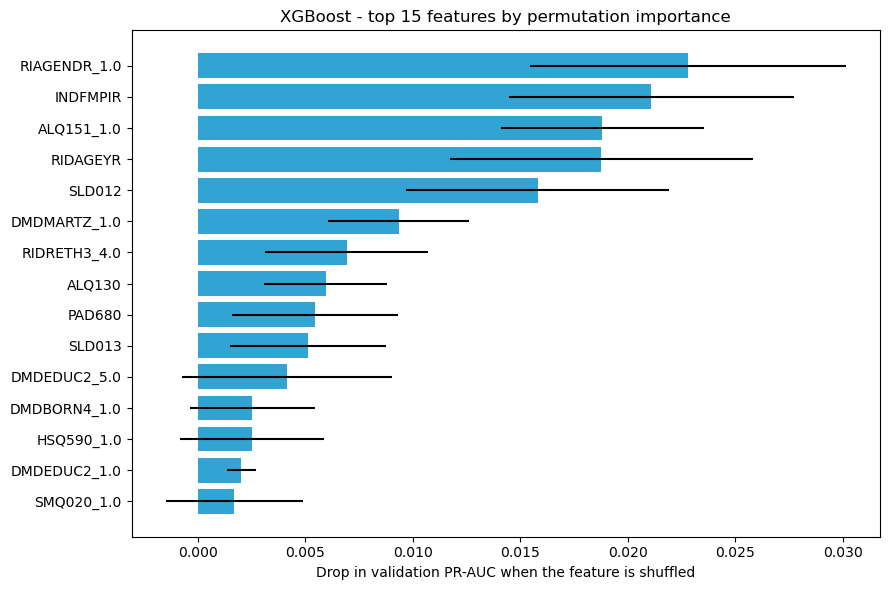

In [10]:
# Plot the 15 most important features
top_importance = importance.head(15).sort_values("Importance_Mean")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top_importance["Feature"],
    top_importance["Importance_Mean"],
    xerr=top_importance["Importance_Std"],
    color="#32a4d4",
)
ax.set_xlabel("Drop in validation PR-AUC when the feature is shuffled")
ax.set_title("XGBoost - top 15 features by permutation importance")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "xgboost_permutation_importance.png"), dpi=150)
plt.show()

#### Threshold tuning

The default 0.5 cut-off is arbitrary for imbalanced data. Here we pick the threshold that
maximizes F1 **on the validation set**, then reuse that exact number on test.

Note for the write-up: in a screening context, recall usually matters more than precision -
missing a depressed respondent is worse than flagging someone for a follow-up question.

In [11]:
# Search the precision-recall curve for the threshold with the best F1 score
def best_f1_threshold(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y, proba)

    # The curve returns one more precision/recall point than thresholds, so trim the last one
    precision, recall = precision[:-1], recall[:-1]

    # Guard against a zero denominator when precision and recall are both zero
    denominator = np.where((precision + recall) == 0, 1, (precision + recall))
    f1 = 2 * precision * recall / denominator

    best_index = f1.argmax()
    return thresholds[best_index], f1[best_index]


xgb_threshold, xgb_best_val_f1 = best_f1_threshold(xgb_model, X_val_tree, y_val)
print(f"Best threshold by validation F1: {xgb_threshold:.4f}  (F1={xgb_best_val_f1:.4f})")

Best threshold by validation F1: 0.5808  (F1=0.3239)


In [12]:
# Score validation at the tuned threshold so the two are comparable.
xgb_val_tuned = score_model(xgb_model, X_val_tree, y_val, threshold=xgb_threshold)
board.add("XGBoost", "Validation (tuned threshold)", xgb_val_tuned)

print("XGBoost - validation, at the tuned threshold")
for k, v in xgb_val_tuned.items():
    print(f"  {k:<10} {v:.4f}")

XGBoost - validation, at the tuned threshold
  PR_AUC     0.2383
  ROC_AUC    0.7087
  Recall     0.4383
  Precision  0.2569
  F1         0.3239
  Accuracy   0.7913
  Threshold  0.5808


#### Final test evaluation

This is the **only** place the test set is touched for this model. Nothing above this cell used it.

**Worth raising with the team:** the shared scoreboard collects every model's Test row so all
five can be compared in one table (that's what the Results slide uses). A stricter rule would be
"only the team's single final chosen model ever touches test" - but that's a workflow decision
for the whole team to agree on together, since every model notebook follows this same pattern.

In [13]:
# Score the winning model on the held-out test set using its tuned threshold
xgb_test = score_model(xgb_model, X_test_tree, y_test, threshold=xgb_threshold)
board.add("XGBoost", "Test", xgb_test)

# Show the full comparison table, PR-AUC first because of class imbalance
results = board.to_frame()
display(results.round(4))

,Model,Split,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,XGBoost,Test,0.2716,0.6813,0.4468,0.2365,0.3093,0.7723,0.5808
1,XGBoost,Validation,0.2383,0.7087,0.6000,0.2111,0.3123,0.6985,0.5000
2,XGBoost,Validation (tuned threshold),0.2383,0.7087,0.4383,0.2569,0.3239,0.7913,0.5808


In [14]:
# Print a confusion matrix and full classification report
def report_model(name, model, X, y, threshold):
    pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int)
    print(f"\n{'=' * 60}\n{name} - test set (threshold {threshold:.3f})\n{'=' * 60}")
    print(pd.DataFrame(
        confusion_matrix(y, pred),
        index=["Actual: No", "Actual: Yes"],
        columns=["Pred: No", "Pred: Yes"],
    ))
    print()
    print(classification_report(y, pred, target_names=["No depression", "Depression"], digits=3))


report_model("XGBoost", xgb_model, X_test_tree, y_test, xgb_threshold)


XGBoost - test set (threshold 0.581)
             Pred: No  Pred: Yes
Actual: No       1486        339
Actual: Yes       130        105

               precision    recall  f1-score   support

No depression      0.920     0.814     0.864      1825
   Depression      0.236     0.447     0.309       235

     accuracy                          0.772      2060
    macro avg      0.578     0.631     0.586      2060
 weighted avg      0.842     0.772     0.800      2060



#### Save model and results

The scoreboard CSV is shared. When this notebook calls `Scoreboard.save(SCOREBOARD_CSV)`,
its rows are appended to the same table the Random Forest / Logistic Regression (and
CatBoost / SVM) notebooks write to, so the final report can read one file.

In [15]:
# Persist the fitted model with its tuned threshold and column order
joblib.dump(
    {"model": xgb_model, "threshold": xgb_threshold, "columns": list(X_train_tree.columns), "params": best_xgb_params},
    os.path.join(MODEL_DIR, "xgboost_seed42.joblib"),
)

# Write the shared scoreboard
final_board = board.save(SCOREBOARD_CSV)

# Save the interpretation table for the written report
importance.to_csv(os.path.join(MODEL_DIR, "xgboost_permutation_importance.csv"), index=False)

print("Saved:")
print(f"  {MODEL_DIR}/xgboost_seed42.joblib")
print(f"  {SCOREBOARD_CSV}")
display(final_board.round(4))

Saved:
  .\Models/xgboost_seed42.joblib
  .\Models\model_scoreboard.csv


,Model,Split,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,XGBoost,Test,0.2716,0.6813,0.4468,0.2365,0.3093,0.7723,0.5808
1,XGBoost,Validation,0.2383,0.7087,0.6000,0.2111,0.3123,0.6985,0.5000
2,XGBoost,Validation (tuned threshold),0.2383,0.7087,0.4383,0.2569,0.3239,0.7913,0.5808
